# Урок 1.1. Обучение с учителем: данные, модель, ошибка

**Интерактивная версия:** `lessons/lesson_1_1/web/index.html`

После урока вы сможете:
- читать таблицу данных и обозначения $x_i$, $x_{ij}$, $y_i$, $X$, $y$;
- объяснить модель данных $y = f(x) + \varepsilon$ и почему шум — нижняя граница ошибки;
- вручную посчитать остатки, MSE, RMSE, MAE и $R^2$;
- объяснить обучение как поиск минимума ошибки по параметрам;
- честно оценить модель на тестовой выборке и понимать, насколько шумна эта оценка.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gbcourse import GBRegressor, RegressionTree, datasets, style
from gbcourse.metrics import mse
from gbcourse.plotting import plot_data, plot_residuals, plot_truth, use_course_style

use_course_style()

## 1. Данные: объекты, признаки, ответы

Шесть квартир из урока 1, но теперь с четырьмя признаками. Строка — объект $x_i$, столбец — признак,
последний столбец — ответ $y$.

In [2]:
flats = pd.DataFrame({
    "area": [30, 40, 50, 60, 70, 80],  # площадь, м²
    "floor": [5, 9, 1, 3, 12, 7],
    "district": ["Север", "Центр", "Юг", "Центр", "Север", "Центр"],
    "metro": [15, 5, 20, 10, 8, 6],  # до метро, мин
    "price": [3, 5, 4, 8, 9, 13],  # цена, млн — целевая переменная
})
X_flats = flats.drop(columns="price")  # матрица признаков n × d
y_flats = flats["price"]  # вектор ответов
print("X:", X_flats.shape, " y:", y_flats.shape)
print("объект x_3:", X_flats.iloc[2].astype(str).tolist(), "→ y_3 =", y_flats.iloc[2])
print("x_32 (этаж объекта 3) =", X_flats.iloc[2, 1])
flats

X: (6, 4)  y: (6,)
объект x_3: ['50', '1', 'Юг', '20'] → y_3 = 4
x_32 (этаж объекта 3) = 1


,area,floor,district,metro,price
0,30,5,Север,15,3
1,40,9,Центр,5,5
2,50,1,Юг,20,4
3,60,3,Центр,10,8
4,70,12,Север,8,9
5,80,7,Центр,6,13


Категориальный признак «район» перед обучением нужно превратить в числа. Самый простой способ —
отдельный столбец 0/1 на каждую категорию (one-hot); подробно — урок 10.1.

In [3]:
pd.get_dummies(X_flats, columns=["district"], dtype=int)

,area,floor,metro,district_Север,district_Центр,district_Юг
0,30,5,15,1,0,0
1,40,9,5,0,1,0
2,50,1,20,0,0,1
3,60,3,10,0,1,0
4,70,12,8,1,0,0
5,80,7,6,0,1,0


## 2. Откуда берутся данные: $y = f(x) + \varepsilon$

Учебный набор «волна с трендом»: $f(x) = \sin x + 0.3x$, шум $\sigma = 0.4$. Даже идеальная модель $F = f$
ошибается на этих точках в среднем примерно на $\sigma^2 = 0.16$.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


средний квадрат шума на 40 точках: 0.1821   σ² = 0.1600


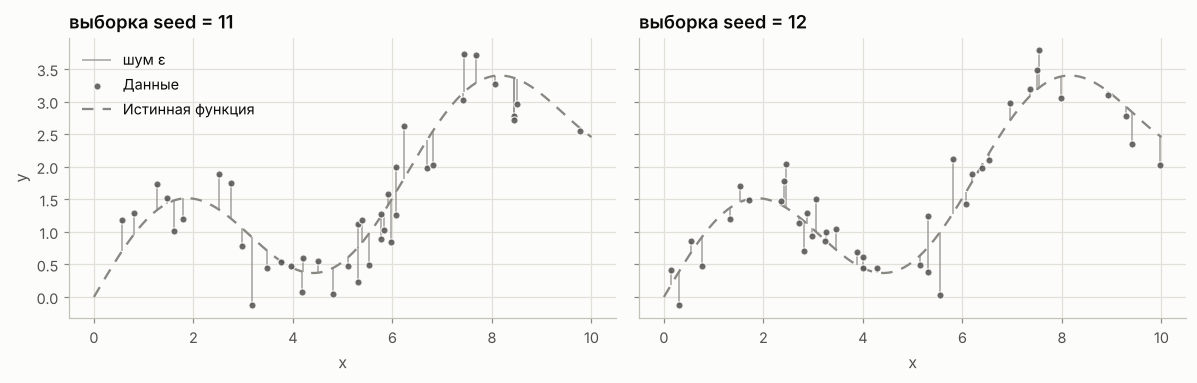

средний квадрат шума при n = 10, 100, 1000, 10000: [0.0811 0.1407 0.1605 0.1603]


In [4]:
X, y = datasets.regression_1d(kind="wave", n=40, noise=0.4, seed=11)
f = datasets.true_function("wave", X[:, 0])
print(f"средний квадрат шума на 40 точках: {np.mean((y - f) ** 2):.4f}   σ² = {0.4 ** 2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, seed in zip(axes, (11, 12)):
    Xs, ys = datasets.regression_1d(kind="wave", n=40, noise=0.4, seed=seed)
    plot_residuals(ax, Xs, ys, datasets.true_function("wave", Xs[:, 0]), label="шум ε")
    plot_data(ax, Xs, ys)
    plot_truth(ax, "wave")
    ax.set(title=f"выборка seed = {seed}", xlabel="x")
axes[0].set_ylabel("y")
axes[0].legend()
fig.tight_layout()
plt.show()

big = [np.mean((ys - datasets.true_function("wave", Xs[:, 0])) ** 2)
       for Xs, ys in [datasets.regression_1d(kind="wave", n=n, noise=0.4, seed=1) for n in (10, 100, 1000, 10000)]]
print("средний квадрат шума при n = 10, 100, 1000, 10000:", np.round(big, 4))

## 3. Ошибка руками: правило риелтора $F(x) = 0.2x - 4$

In [5]:
x6 = flats["area"].to_numpy(float)
y6 = flats["price"].to_numpy(float)
F6 = 0.2 * x6 - 4
r6 = y6 - F6
table = pd.DataFrame({"x": x6, "y": y6, "F(x)": F6, "r": r6, "|r|": np.abs(r6), "r²": r6**2})
print(table.to_string(index=False))
sse, sse0 = np.sum(r6**2), np.sum((y6 - y6.mean()) ** 2)
print(f"\nсумма остатков = {r6.sum():.1f} (ошибки взаимно гасятся!)")
print(f"MSE = {sse / 6:.4f}  RMSE = {np.sqrt(sse / 6):.4f} млн  MAE = {np.mean(np.abs(r6)):.4f} млн")
print(f"R² = 1 − {sse:.0f}/{sse0:.0f} = {1 - sse / sse0:.4f}")
a, b = np.polyfit(x6, y6, 1)
print(f"лучшая прямая: a = {a:.4f}, b = {b:.4f}, SSE = {np.sum((y6 - a * x6 - b) ** 2):.4f}")

   x    y  F(x)    r  |r|  r²
30.0  3.0   2.0  1.0  1.0 1.0
40.0  5.0   4.0  1.0  1.0 1.0
50.0  4.0   6.0 -2.0  2.0 4.0
60.0  8.0   8.0  0.0  0.0 0.0
70.0  9.0  10.0 -1.0  1.0 1.0
80.0 13.0  12.0  1.0  1.0 1.0

сумма остатков = 0.0 (ошибки взаимно гасятся!)
MSE = 1.3333  RMSE = 1.1547 млн  MAE = 1.0000 млн
R² = 1 − 8/70 = 0.8857
лучшая прямая: a = 0.1886, b = -3.3714, SSE = 7.7714


Выброс (квартира №6 «стоит» 30 млн) по-разному влияет на метрики: квадрат раздувает большие ошибки.

In [6]:
y_out = y6.copy()
y_out[5] = 30
r_out = y_out - F6
print(f"с выбросом: MSE = {np.mean(r_out**2):.2f}, RMSE = {np.sqrt(np.mean(r_out**2)):.2f}, MAE = {np.mean(np.abs(r_out)):.2f}")

с выбросом: MSE = 55.17, RMSE = 7.43, MAE = 3.83


## 4. Обучение = поиск дна рельефа ошибки

Для 40 точек «волны» нарисуем MSE как функцию параметров константы и прямой и найдём минимумы.

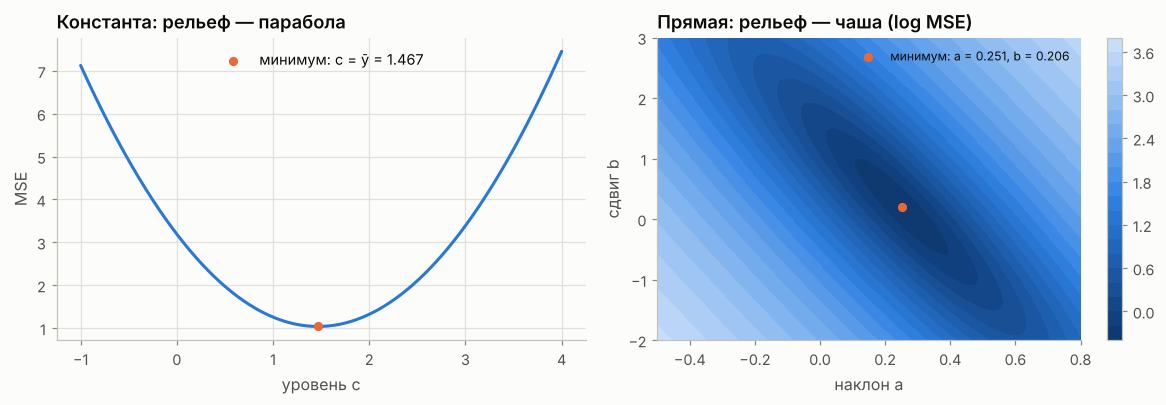

константа: MSE = 1.0384
прямая:    MSE = 0.7056
ступенька: порог = 6.156, MSE = 0.3115


In [7]:
cs = np.linspace(-1, 4, 501)
mse_c = [np.mean((y - c) ** 2) for c in cs]
A, B = np.meshgrid(np.linspace(-0.5, 0.8, 140), np.linspace(-2, 3, 140))
mse_ab = np.mean((y[None, None, :] - (A[..., None] * X[:, 0] + B[..., None])) ** 2, axis=-1)
a_opt, b_opt = np.polyfit(X[:, 0], y, 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(cs, mse_c, color=style.BLUE)
axes[0].scatter([y.mean()], [np.mean((y - y.mean()) ** 2)], color=style.ORANGE, zorder=3, label=f"минимум: c = ȳ = {y.mean():.3f}")
axes[0].set(xlabel="уровень c", ylabel="MSE", title="Константа: рельеф — парабола")
axes[0].legend()
cf = axes[1].contourf(A, B, np.log(mse_ab), levels=20, cmap=style.cmap_sequential().reversed())
axes[1].scatter([a_opt], [b_opt], color=style.ORANGE, zorder=3, label=f"минимум: a = {a_opt:.3f}, b = {b_opt:.3f}")
axes[1].set(xlabel="наклон a", ylabel="сдвиг b", title="Прямая: рельеф — чаша (log MSE)")
axes[1].legend(loc="upper right", fontsize=8)
fig.colorbar(cf, ax=axes[1])
fig.tight_layout()
plt.show()

stump = RegressionTree(max_depth=1).fit(X, -y)
print(f"константа: MSE = {np.mean((y - y.mean()) ** 2):.4f}")
print(f"прямая:    MSE = {np.mean((y - a_opt * X[:, 0] - b_opt) ** 2):.4f}")
print(f"ступенька: порог = {stump.nodes[0].threshold:.3f}, MSE = {mse(y, stump.predict(X)):.4f}")

Чем гибче модель, тем ниже её лучшая MSE на обучении. Но это ещё не значит, что она лучше на новых данных.

## 5. Обучение и тест: честная оценка

50 точек делим на обучение (35) и тест (15) 30 разными способами. Ошибка на тесте у дерева глубины 3
сильно зависит от разбиения.

разбиение 0: обучение 0.1196, тест 0.3209
тест по 30 разбиениям: от 0.125 до 0.521, среднее 0.301
обучение в среднем: 0.114  (оптимистично)


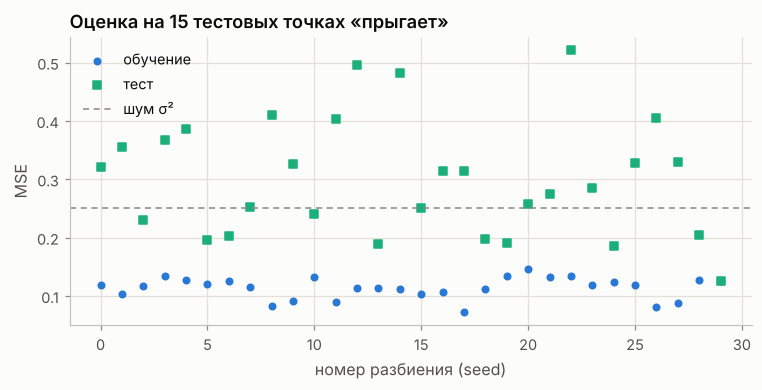

In [8]:
Xw, yw = datasets.regression_1d(kind="wave", n=50, noise=0.5, seed=21)
rows = []
for seed in range(30):
    Xtr, Xte, ytr, yte = datasets.train_test_split(Xw, yw, test_size=0.3, seed=seed)
    tree = RegressionTree(max_depth=3).fit(Xtr, -ytr)
    rows.append((mse(ytr, tree.predict(Xtr)), mse(yte, tree.predict(Xte))))
rows = np.array(rows)
print(f"разбиение 0: обучение {rows[0, 0]:.4f}, тест {rows[0, 1]:.4f}")
print(f"тест по 30 разбиениям: от {rows[:, 1].min():.3f} до {rows[:, 1].max():.3f}, среднее {rows[:, 1].mean():.3f}")
print(f"обучение в среднем: {rows[:, 0].mean():.3f}  (оптимистично)")

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.scatter(range(30), rows[:, 0], color=style.ROLE["train"], s=18, label="обучение")
ax.scatter(range(30), rows[:, 1], color=style.ROLE["test"], marker="s", s=22, label="тест")
ax.axhline(0.25, color=style.MUTED, ls=(0, (4, 3)), lw=1, label="шум σ²")
ax.set(xlabel="номер разбиения (seed)", ylabel="MSE", title="Оценка на 15 тестовых точках «прыгает»")
ax.legend()
plt.show()

## 6. Глубина дерева: обучение против теста

На 200 точках сравним деревья глубины 0…12. Ошибка на обучении падает всегда, на тесте — до поры.

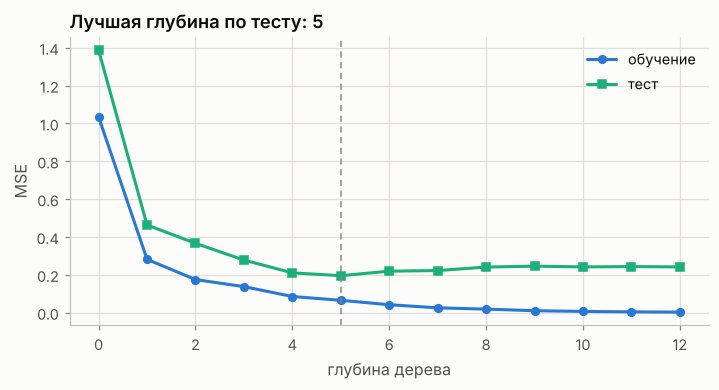

In [9]:
X2, y2 = datasets.regression_1d(kind="wave", n=200, noise=0.4, seed=11)
X_tr, X_te, y_tr, y_te = datasets.train_test_split(X2, y2, test_size=0.3, seed=0)
depths = range(0, 13)
tr_err, te_err = [], []
for d in depths:
    if d == 0:
        p_tr, p_te = np.full_like(y_tr, y_tr.mean()), np.full_like(y_te, y_tr.mean())
    else:
        t = RegressionTree(max_depth=d).fit(X_tr, -y_tr)
        p_tr, p_te = t.predict(X_tr), t.predict(X_te)
    tr_err.append(mse(y_tr, p_tr))
    te_err.append(mse(y_te, p_te))
best = int(np.argmin(te_err))
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(depths, tr_err, marker="o", color=style.ROLE["train"], label="обучение")
ax.plot(depths, te_err, marker="s", color=style.ROLE["test"], label="тест")
ax.axvline(best, color=style.MUTED, ls=(0, (4, 3)), lw=1)
ax.set(xlabel="глубина дерева", ylabel="MSE", title=f"Лучшая глубина по тесту: {best}")
ax.legend()
plt.show()

## 7. Сверка с scikit-learn: единый интерфейс fit / predict

In [10]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

print("метрики правила риелтора (sklearn):", mean_squared_error(y6, F6), mean_absolute_error(y6, F6), r2_score(y6, F6))
for name, model in {
    "среднее (базовая)": DummyRegressor(),
    "прямая": LinearRegression(),
    "дерево глубины 3": DecisionTreeRegressor(max_depth=3),
    "бустинг": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2),
}.items():
    model.fit(X_tr, y_tr)
    print(f"{name:18s} тест MSE = {mse(y_te, model.predict(X_te)):.3f}")
ours = GBRegressor(n_estimators=100, learning_rate=0.1, max_depth=2).fit(X_tr, y_tr)
print(f"{'gbcourse бустинг':18s} тест MSE = {mse(y_te, ours.predict(X_te)):.3f}")

метрики правила риелтора (sklearn): 1.3333333333333333 1.0 0.8857142857142857
среднее (базовая)  тест MSE = 1.386
прямая             тест MSE = 0.825
дерево глубины 3   тест MSE = 0.278
бустинг            тест MSE = 0.202
gbcourse бустинг   тест MSE = 0.202


## Упражнения

1. Найдите $x_{43}$ в таблице квартир. Существует ли $x_{25}$?
2. Посчитайте MSE, RMSE, MAE и $R^2$ константы «все квартиры по 7 млн».
3. Посчитайте $R^2$ правила $F(x) = 0.3x - 4$ и объясните знак.
4. Переберите константу на сетке и убедитесь, что минимум MSE — среднее.
5. Повторите сравнение глубин из раздела 6 для `noise=0.1` и `noise=1.0`. Как шум влияет на лучшую глубину?
6. Повторите эксперимент раздела 5 с долей теста 10 % и 50 %. Как меняется разброс оценки?

<details><summary>Решения</summary>

`python lessons/lesson_1_1/exercises/solutions.py`
</details>